In [68]:
using LinearAlgebra
using Plots
using Plots.Measures

default(leftmargin = 5mm, bottommargin = 5mm, rightmargin = 5mm)


In [3]:
struct Reflector{T}
    v::Vector{T}
    beta::T
end

function reflector(x)
    sign_x1 = x[1] >= 0 #True se positivo, False, se não
    norm_x = norm(x)

    v = copy(x)
    v[1] -= norm_x

    if sign_x1
        beta = (norm_x + x[1])/(norm_x * sum(abs2, @view x[2:end])) 
    else
        beta = 1/(norm_x*(norm_x - x[1]))
    end

    return Reflector(v, beta)
end

reflector (generic function with 1 method)

e) Estabilidade. Teste sua função com vetores x tanto Float64 quanto Float32, e com
pare os resultados.
Dica: verifique que a resposta está sendo automaticamente calculada no tipo certo. Se você
passar um vetor Float32 e receber um Float64 de resposta, alguma conta está “promovendo
tipos”. Uma dica é não ter constantes não-inteiras como 1.0, que são interpretadas como Float64.

In [13]:
function compare_reflector_results(x, show_results = false)
    x_64 = Float64.(x)
    x_32 = Float32.(x)

    r_64 = reflector(x_64)
    r_32 = reflector(x_32)

    norm_dif = norm(r_64.v - r_32.v)

    if show_results

    end
    println("Norma da diferença = $norm_dif")
    println("Float 64: Beta = $(r_64.beta)")
    println("Float 32: Beta = $(r_32.beta)")

end

compare_reflector_results (generic function with 2 methods)

f) Escreva uma função calc_beta(v) que calcula β unicamente a partir de v. Repita
os testes Float64 e Float32 usando esta função, e compare os resultados com a função
anterior. Observe que não há muita diferença ao calcular β a partir de x ou apenas de v,
mesmo com x quase alinhado com e1.

In [4]:
function calc_beta(v)   
    v_dot = sum(abs2, v)
    return 2/v_dot
end

calc_beta (generic function with 1 method)

Questão 2. Forma de Hessemberg.
Se você se sentir à vontade, pode definir um tipo de dado para os refletores, e então as funções
desta questão poderiam receber e retornar Refletores, ao invés de v e β separadamente.
a) Aplicando refletores. Escreva uma função apply_reflector(v, beta, b) que cal
cula Qvb, onde Qv = I −βvv∗ é o refletor de Householder dado por v e β.

In [5]:
function apply_reflector(v, beta, b)
    n_v = length(v)
    n_b = length(b)

    k = n_b - n_v + 1
    b_view = @view b[k:end]

    alpha = beta .* dot(v, b_view)
    b_view .-= alpha * v
    
    return b
end

apply_reflector (generic function with 1 method)

In [6]:
b = rand(10)
display(b)
r = reflector(b)
apply_reflector(r.v, r.beta, b)

10-element Vector{Float64}:
 0.8860603664230763
 0.46014336899991404
 0.6398589727934281
 0.41237465364134673
 0.07654009521128524
 0.007061766468539288
 0.7855272332254832
 0.9785463246028628
 0.10510032006204473
 0.8715942962626014

10-element Vector{Float64}:
 1.9818032560822925
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

b) Testes. Verifique que sua função está correta, aplicando em vetores x de mesma dimen
são que v, e depois para vetores de dimensões maiores do que v (adaptando, se necessário,
sua função para funcionar neste caso). Certifique-se que sua função tem complexidade
O(n), onde n é a dimensão do vetor de entrada

c) Generalize sua função para apply_reflector(v, beta, A) que calcula QvA para uma
matriz A (com no mínimo o mesmo número de linhas do que v).

In [7]:
function apply_reflector(v, beta, A)
    n_v = length(v)
    m, n = size(A)

    if m >= n_v
        k = m - n_v + 1

        A_view = @view A[k:end,:]
        vA = v'*A_view
        beta_v = beta .* v
        A_view .-= beta_v * vA
    
        return A
    end
end

apply_reflector (generic function with 1 method)

In [8]:
function rev_apply_reflector(v, beta, A)
    n_v = length(v)
    m, n = size(A)

    if n >= n_v
        k = n - n_v + 1

        A_view = @view A[:,k:end]
        Av = A_view*v
        beta_v = beta .* v'
        A_view .-=  Av * beta_v
    
        return A
    end
end



rev_apply_reflector (generic function with 1 method)

In [9]:
function to_hessemberg(A; return_Q = false)
    H = copy(A)
    m, n = size(H)
    reflectors = []

    if return_Q
        Q = Matrix{eltype(H)}(I, n, n)
    end

    for j in 1:(n-2)
        x = @view H[(j+1):end,j]

        r = reflector(x)
        push!(reflectors, r)

        apply_reflector(r.v, r.beta, @view H[(j+1):end, j:end])
        rev_apply_reflector(r.v, r.beta, @view H[:, (j+1):end])

        if return_Q
            rev_apply_reflector(r.v, r.beta, @view Q[:, (j+1):end])
        end
    end

    if return_Q
        return reflectors, H, Q
    else
        return reflectors, H
    end
end

to_hessemberg (generic function with 1 method)

In [ ]:
function plot_eigen_values(w_max; ascending= true, imag_only= false)

    if ascending
        range = 0.0:0.03:w_max
    else
        range = w_max:-0.03:0.0
    end

    if imag_only
        im_lambda1 = Float64[]
        im_lambda2 = Float64[]
        
        for w in range
            A = [0.0 1.0; -w^2 0.0]
            
            eigen_A = eigen(A)

            push!(im_lambda1, imag(eigen_A.values[1]))
            push!(im_lambda2, imag(eigen_A.values[2]))
        end
        
        p1 = scatter(range, im_lambda1, label="Imag(λ₁)", linewidth=2, color=:red, title="Autovalores", xlabel="w", ylabel="Parte Imaginária")
        scatter!(p1, range, im_lambda2, label="Imag(λ₂)", linewidth=2, color=:blue)
    
        if ascending
            display(scatter(p1, size=(600, 400)))
        else
            display(scatter(p1, size=(600, 400), x_flip= true))
        end

    else
        real_lambda1 = Float64[]
        real_lambda2 = Float64[]
        im_lambda1 = Float64[]
        im_lambda2 = Float64[]
        
        for w in range
            A = [0.0 1.0; -w^2 0.0]
            
            eigen_A = eigen(A)

            push!(real_lambda1, real(eigen_A.values[1]))
            push!(real_lambda2, real(eigen_A.values[2]))
            push!(im_lambda1, imag(eigen_A.values[1]))
            push!(im_lambda2, imag(eigen_A.values[2]))
        end
        
        p1 = scatter(real_lambda1, im_lambda1, label="(λ₁)", linewidth=2, color=:red, title="Autovalores", xlabel="w", ylabel="Parte Imaginária")
        scatter!(p1, real_lambda2, im_lambda2, label="(λ₂)", linewidth=2, color=:blue)
    
        if ascending
            display(scatter(p1, size=(600, 400)))
        else
            display(scatter(p1, size=(600, 400), x_flip= true))
        end
    end
    

end

plot_eigen_values (generic function with 1 method)

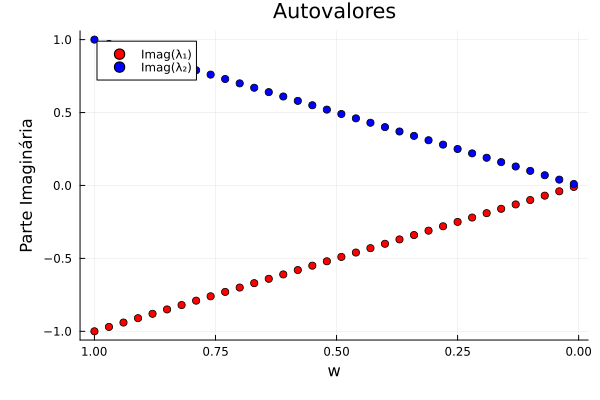

In [45]:
plot_eigen_values(1; ascending= false, imag_only= true)

In [14]:
function plot_eigen_values(w_max; ascending= true, imag_only= false)

    if ascending
        range = 0.0:0.2:w_max
    else
        range = w_max:-0.03:0.0
    end

    for w in range
        println("----------------")
        println("w = $w")
        A = [0.0 1.0; -w^2 0.0]
        eigen_A = eigen(A)
        println(eigen_A.values)
        println(eigen_A.vectors[:,1])
        println(eigen_A.vectors[:,2])

        println("----------------")
    end
end

plot_eigen_values (generic function with 1 method)

In [70]:
function plot_eigen_vectors(w_max; ascending= true)

    if ascending
        range = 0.0:0.05:w_max
    else
        range = w_max:-0.03:0.0
    end

    real_v1 = Float64[]
    real_v2 = Float64[]
    imag_v1 = Float64[]
    imag_v2 = Float64[]
    

    for w in range
        A = [0.0 1.0; -w^2 0.0]
        eigen_A = eigen(A)

        v1 = eigen_A.vectors[:,1]
        v2 = eigen_A.vectors[:,2]

        r_v1 = real(v1[1])
        r_v2 = real(v2[1])
        im_v1 = imag(v1[2])
        im_v2 = imag(v2[2])

        push!(real_v1, r_v1)
        push!(real_v2, r_v2)
        push!(imag_v1, im_v1)
        push!(imag_v2, im_v2)

    end

    # p1 = scatter(range, real_v1, title= "v1 real")
    # p2 = scatter(range, real_v2, title = "v2 real")
    # p3 = scatter(range, imag_v1)
    # p4 = scatter(range, imag_v2)

    p1 = scatter(real_v1, xlims = (0,1), ylims = (-1,1), imag_v1, title= "v1")
    p2 = scatter(real_v2, xlims = (0,1), ylims = (-1,1), imag_v2, title = "v2")

    # plot(p1, p3, p2, p4, layout= (1,2), size= (800,800), x_flip= true)
    plot(p1, p2, layout= (1,2), size= (800,400))

end

plot_eigen_vectors (generic function with 1 method)

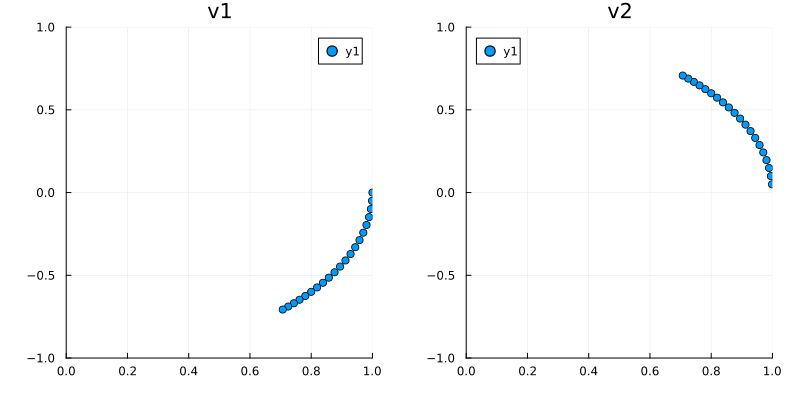

In [71]:
plot_eigen_vectors(1, ascending= true)